In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/Combined Order List - Copy.xlsx')
df.head()

,PO No.,PO Date,WO,Sr. No.,Material,Unnamed: 5,Qty,Item,Size,Class,...,Freight,Total Expense,Cost,Profit,Unnamed: 25,Unit Rate,Unit Rate.1,Quoted Unit Rate,PO Rate,ID No.
0,210/240406629,2021-11-11,WO32,1,2001733192,NaN,110,SPADE,"1""",150,...,7,57,112.0,0.09,10.08,122.08,122,137.0,155.0,NaN
1,210/240406629,2021-11-11,WO32,2,2001733167,NaN,40,SPADE,"1""",300,...,7,57,124.0,0.09,11.16,135.16,135,150.0,170.0,NaN
2,210/240406629,2021-11-11,WO32,3,2001733218,NaN,60,SPADE,"2""",300,...,8,65,190.0,0.09,17.10,207.10,207,229.0,265.0,NaN
3,363/240409652,2021-11-23,WO33,1,2001437217,NaN,1,SB,"1.5""",150,...,200,320,640.0,0.15,96.00,736.00,750,NaN,750.0,NaN
4,363/240409652,2021-11-23,WO33,2,2001437217,NaN,2,SB,"1.5""",150,...,200,320,640.0,0.15,96.00,736.00,750,NaN,750.0,NaN


In [ ]:
# Selecting the key columns related to price and cost for descriptive statistics
price_cost_cols = [
    'Mat Cost',     # Material cost
    'Fab',          # Fabrication cost
    'Testing',      # Testing cost for functionality
    'P+F',          # Packing and Finishing cost
    'PMI',          # Positive Material Identification test cost
    'Freight',      # Transportation cost
    'Total Expense',# Combined operational expenses (Freight + Testing + PMI + P+F + Fab)
    'Cost',         # Total cost (Total Expense + Material Cost)
    'Profit',       # Profit (either percentage or rupees per unit)
    'Quoted Unit Rate', # Initially quoted unit rate before negotiation
    'PO Rate'       # Final purchase order rate after negotiation
]

# Generate descriptive statistics for cost-related columns
df[price_cost_cols].describe().T  # .T transposes for easier readability


,count,mean,std,min,25%,50%,75%,max
Mat Cost,2797.0,3823.557469,20797.095334,40.00,360.00,990.00,2950.00,950000.0
Fab,2797.0,164.880229,201.375709,0.00,70.00,120.00,180.00,6000.0
Testing,2797.0,69.449768,285.959175,0.00,15.00,30.00,50.00,12000.0
P+F,2797.0,71.472292,66.554836,0.00,30.00,50.00,100.00,1800.0
PMI,2794.0,27.415891,90.825251,0.00,0.00,0.00,50.00,3500.0
Freight,2797.0,174.031105,234.831651,7.00,70.00,100.00,200.00,7000.0
Total Expense,2797.0,506.548445,729.208226,38.00,205.00,360.00,600.00,27200.0
Cost,2797.0,4329.596439,21421.248816,112.00,590.00,1390.00,3640.00,977200.0
Profit,2797.0,0.925819,22.911340,0.06,0.13,0.16,0.20,700.0
Quoted Unit Rate,2757.0,4942.690584,23739.142165,130.00,715.00,1685.00,4200.00,1080000.0


In [ ]:
type(df)

pandas.core.frame.DataFrame

In [ ]:
df.shape

(2797, 31)

Checked for null values. 'Description' column removed in excel as it was simplified into multiple columns by the client.

In [ ]:
df.isnull().sum()

,0
PO No.,0
PO Date,0
WO,0
Sr. No.,0
Material,0
Unnamed: 5,2797
Qty,0
Item,0
Size,0
Class,0


In [ ]:
df = df.drop(['Unnamed: 5'], axis = 1)

In [ ]:
df.shape

(2797, 30)

Unnamed 15 dropped after client meeting.

In [ ]:
df = df.drop(['Unnamed: 15'], axis = 1)

In [ ]:
df.shape

(2797, 29)

In [ ]:
df.head(2)

,PO No.,PO Date,WO,Sr. No.,Material,Qty,Item,Size,Class,Material.1,...,Freight,Total Expense,Cost,Profit,Unnamed: 25,Unit Rate,Unit Rate.1,Quoted Unit Rate,PO Rate,ID No.
0,210/240406629,2021-11-11,WO32,1,2001733192,110,SPADE,"1""",150,IS2062-B,...,7,57,112.0,0.09,10.08,122.08,122,137.0,155.0,NaN
1,210/240406629,2021-11-11,WO32,2,2001733167,40,SPADE,"1""",300,IS2062-B,...,7,57,124.0,0.09,11.16,135.16,135,150.0,170.0,NaN


In [ ]:
df.isnull().sum()

,0
PO No.,0
PO Date,0
WO,0
Sr. No.,0
Material,0
Qty,0
Item,0
Size,0
Class,0
Material.1,0


OD, ID and T has same no. of nulls. why?

In [ ]:
df.columns

Index(['PO No.', 'PO Date', 'WO', 'Sr. No.', 'Material', 'Qty', 'Item', 'Size',
       'Class', 'Material.1', 'OD', 'ID', 'T', 'T (RF)', 'Mat Cost', 'Fab',
       'Testing', 'PMI', 'P+F', 'Freight', 'Total Expense', 'Cost', 'Profit',
       'Unnamed: 25', 'Unit Rate', 'Unit Rate.1', 'Quoted Unit Rate',
       'PO Rate', 'ID No.'],
      dtype='object')

The above cell returns and index object which is like and array and below is a fn to know the no. of elements in it(or the size).

In [ ]:
df['plant code'] = df['PO No.'].apply(lambda x: x.rsplit('/', 1)[0] if '/' in str(x) else '')

df['PO No.'] = df['PO No.'].apply(lambda x: x.rsplit('/', 1)[-1])

In [ ]:
df.head(2)

,PO No.,PO Date,WO,Sr. No.,Material,Qty,Item,Size,Class,Material.1,...,Total Expense,Cost,Profit,Unnamed: 25,Unit Rate,Unit Rate.1,Quoted Unit Rate,PO Rate,ID No.,plant code
0,240406629,2021-11-11,WO32,1,2001733192,110,SPADE,"1""",150,IS2062-B,...,57,112.0,0.09,10.08,122.08,122,137.0,155.0,NaN,210
1,240406629,2021-11-11,WO32,2,2001733167,40,SPADE,"1""",300,IS2062-B,...,57,124.0,0.09,11.16,135.16,135,150.0,170.0,NaN,210


In [ ]:
df['PO No.'].iloc[224:]

,PO No.
224,240440408
225,240440408
226,240440408
227,240440408
228,240440408
...,...
2792,240845945
2793,240845945
2794,240845945
2795,240845945


In [ ]:
df['plant code'].iloc[224:]

,plant code
224,HPRJ/363
225,HPRJ/363
226,HPRJ/363
227,HPRJ/363
228,HPRJ/363
...,...
2792,363
2793,363
2794,363
2795,363


letters in plant code??

In [ ]:
df['plant code'].isnull().sum()

0

In [ ]:
df['plant code']

,plant code
0,210
1,210
2,210
3,363
4,363
...,...
2792,363
2793,363
2794,363
2795,363


In [ ]:
np.sum(df.dtypes==np.int64)

9

In [ ]:
int_cols = df.select_dtypes(include=np.int64).columns
print(int_cols)

Index(['Sr. No.', 'Material', 'Qty', 'Fab', 'Testing', 'P+F', 'Freight',
       'Total Expense', 'Unit Rate.1'],
      dtype='object')


In [ ]:
int_cols.isnull().sum()

0

In [ ]:
df[int_cols].drop('Unit Rate.1')

KeyError: "['Unit Rate.1'] not found in axis"

<Axes: >

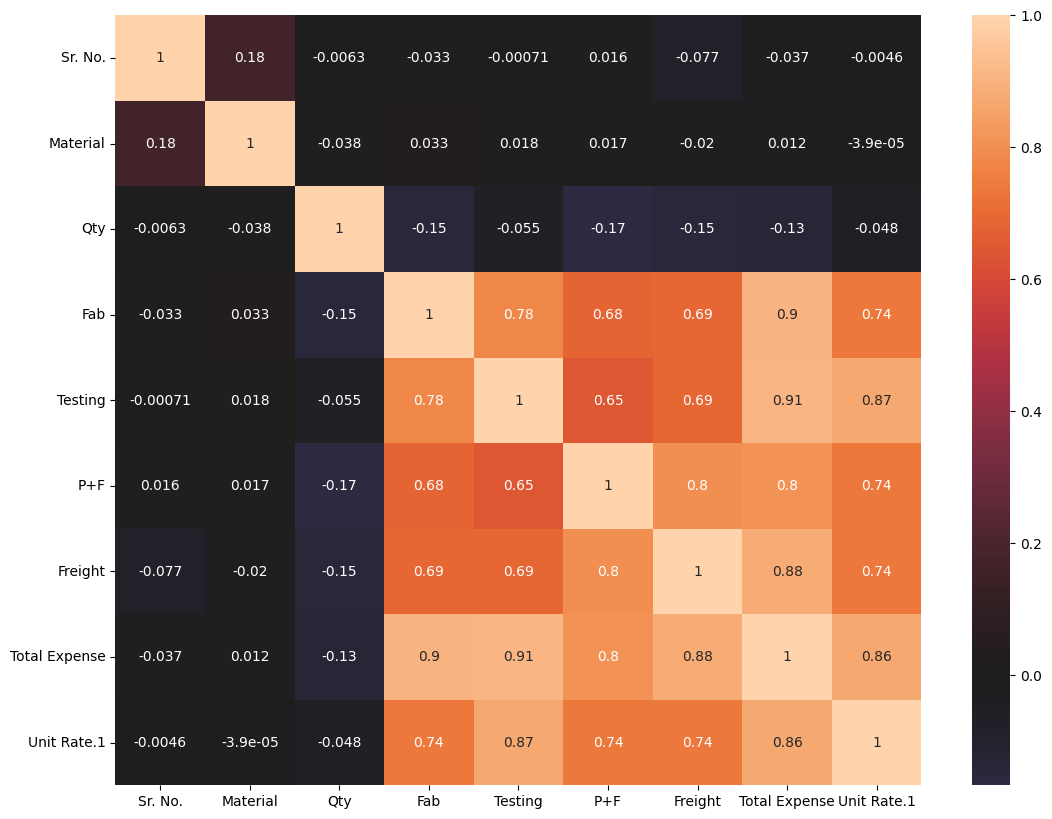

In [ ]:
plt.figure(figsize=(13,10))
sns.heatmap(df[int_cols].corr(), center=0, annot=True)

In [ ]:
df.drop(columns = ['Unit Rate.1'], inplace=True)

In [ ]:
df.shape

(2797, 29)

In [ ]:
int_cols = df.select_dtypes(include=np.int64).columns
print(int_cols)

Index(['Sr. No.', 'Material', 'Qty', 'Fab', 'Testing', 'P+F', 'Freight',
       'Total Expense'],
      dtype='object')


<Axes: >

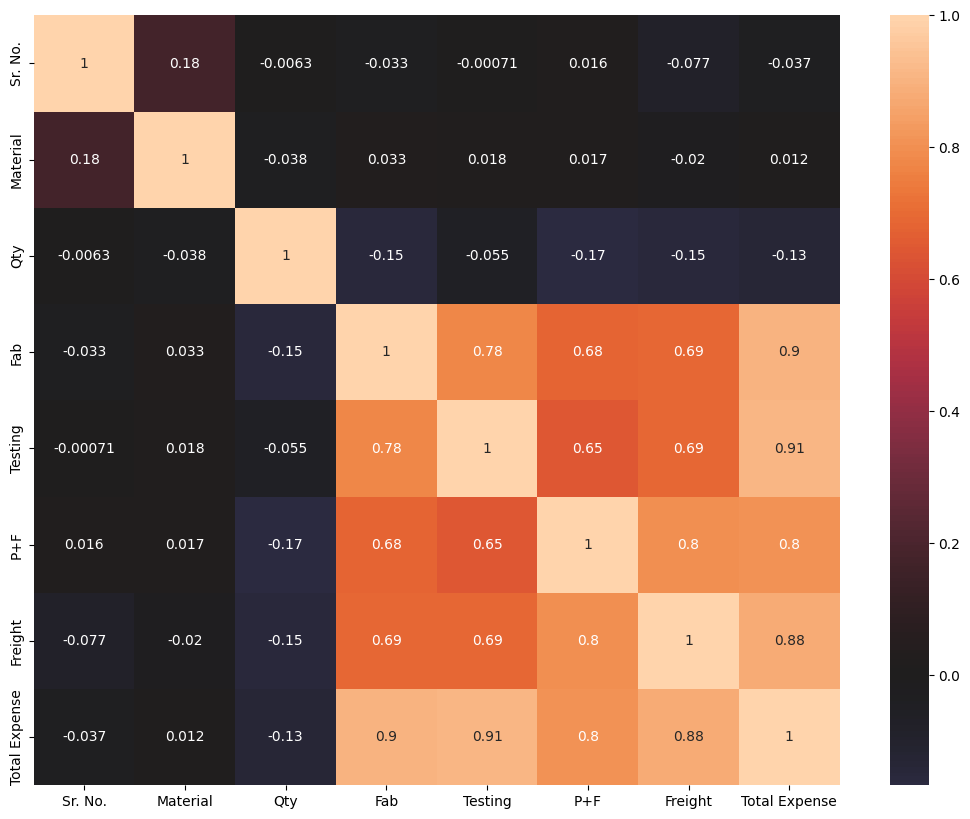

In [ ]:
plt.figure(figsize=(13,10))
sns.heatmap(df[int_cols].corr(), center=0, annot=True)

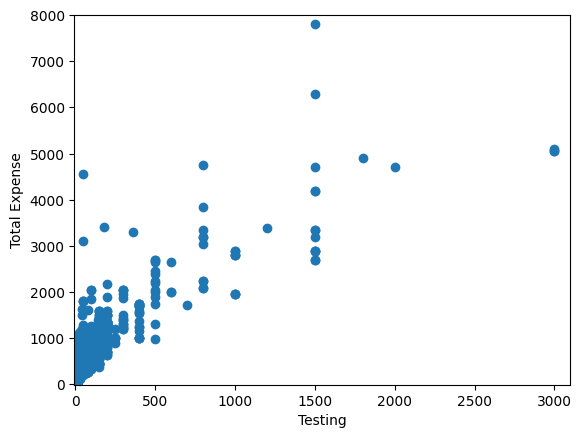

In [ ]:
plt.scatter(df['Testing'], df['Total Expense'])
plt.xlabel('Testing')
plt.ylabel('Total Expense')
plt.axis([-5,3100,-5,8000])
plt.show()

In [ ]:
df.head()

,PO No.,PO Date,WO,Sr. No.,Material,Qty,Item,Size,Class,Material.1,...,Freight,Total Expense,Cost,Profit,Unnamed: 25,Unit Rate,Quoted Unit Rate,PO Rate,ID No.,plant code
0,240406629,2021-11-11,WO32,1,2001733192,110,SPADE,"1""",150,IS2062-B,...,7,57,112.0,0.09,10.08,122.08,137.0,155.0,NaN,210
1,240406629,2021-11-11,WO32,2,2001733167,40,SPADE,"1""",300,IS2062-B,...,7,57,124.0,0.09,11.16,135.16,150.0,170.0,NaN,210
2,240406629,2021-11-11,WO32,3,2001733218,60,SPADE,"2""",300,IS2062-B,...,8,65,190.0,0.09,17.10,207.10,229.0,265.0,NaN,210
3,240409652,2021-11-23,WO33,1,2001437217,1,SB,"1.5""",150,A516-70,...,200,320,640.0,0.15,96.00,736.00,NaN,750.0,NaN,363
4,240409652,2021-11-23,WO33,2,2001437217,2,SB,"1.5""",150,A516-70,...,200,320,640.0,0.15,96.00,736.00,NaN,750.0,NaN,363


In [ ]:
df.drop(columns = ['Unit Rate'], inplace=True)

In [ ]:
df.shape

(2797, 28)

In [ ]:
df.head()

,PO No.,PO Date,WO,Sr. No.,Material,Qty,Item,Size,Class,Material.1,...,P+F,Freight,Total Expense,Cost,Profit,Unnamed: 25,Quoted Unit Rate,PO Rate,ID No.,plant code
0,240406629,2021-11-11,WO32,1,2001733192,110,SPADE,"1""",150,IS2062-B,...,5,7,57,112.0,0.09,10.08,137.0,155.0,NaN,210
1,240406629,2021-11-11,WO32,2,2001733167,40,SPADE,"1""",300,IS2062-B,...,5,7,57,124.0,0.09,11.16,150.0,170.0,NaN,210
2,240406629,2021-11-11,WO32,3,2001733218,60,SPADE,"2""",300,IS2062-B,...,7,8,65,190.0,0.09,17.10,229.0,265.0,NaN,210
3,240409652,2021-11-23,WO33,1,2001437217,1,SB,"1.5""",150,A516-70,...,30,200,320,640.0,0.15,96.00,NaN,750.0,NaN,363
4,240409652,2021-11-23,WO33,2,2001437217,2,SB,"1.5""",150,A516-70,...,30,200,320,640.0,0.15,96.00,NaN,750.0,NaN,363


In [ ]:
df.drop(columns = ['Quoted Unit Rate'], inplace=True)

In [ ]:
df.shape

(2797, 27)

In [ ]:
exportdf = df[df[['OD','ID','T']].isnull().all(axis=1)]
exportdf

,PO No.,PO Date,WO,Sr. No.,Material,Qty,Item,Size,Class,Material.1,...,PMI,P+F,Freight,Total Expense,Cost,Profit,Unnamed: 25,PO Rate,ID No.,plant code
0,240406629,2021-11-11,WO32,1,2001733192,110,SPADE,"1""",150,IS2062-B,...,NaN,5,7,57,112.0,0.09,10.08,155.0,NaN,210
1,240406629,2021-11-11,WO32,2,2001733167,40,SPADE,"1""",300,IS2062-B,...,NaN,5,7,57,124.0,0.09,11.16,170.0,NaN,210
2,240406629,2021-11-11,WO32,3,2001733218,60,SPADE,"2""",300,IS2062-B,...,NaN,7,8,65,190.0,0.09,17.10,265.0,NaN,210
12,240409672,2021-11-23,WO36,2,2001951280,50,BLFF,"4""",300,IS2062-B,...,0.0,30,60,110,845.0,0.18,152.10,1000.0,NaN,252
13,240409672,2021-11-23,WO36,3,2001951401,120,BLFF,"4""",150,IS2062-B,...,0.0,30,60,110,685.0,0.30,205.50,890.0,NaN,252
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2069,240768020,2024-06-26,WO30,10,2001628811,2,RING,"14""",150,A516-70,...,0.0,80,160,500,3200.0,0.11,352.00,3800.0,NaN,393
2073,240768020,2024-06-26,WO30,14,2001604564,10,SPADE,"14""",150,A516-70,...,0.0,80,150,490,3850.0,0.11,423.50,4300.0,NaN,393
2074,240768020,2024-06-26,WO30,15,2001627063,2,SPADE,"14""",150,A516-70,...,0.0,150,200,500,3900.0,0.20,780.00,4700.0,NaN,393
2079,240768020,2024-06-26,WO30,20,2002305247,1,SPADE,"24""",150,A516-70,...,0.0,150,300,1000,12900.0,0.14,1806.00,14800.0,NaN,393


In [ ]:
exportdf.isnull().sum()

NameError: name 'exportdf' is not defined

In [ ]:
exportdf.to_excel('/content/drive/MyDrive/exportdf.xlsx', index=False)

In [ ]:
df['Size'].value_counts()

,count
Size,
"2""",381
"3""",290
"6""",277
"4""",244
"8""",226
"10""",204
"1""",201
"12""",165
"1.5""",157


In [ ]:
df['Size'].dtype

dtype('O')

In [ ]:
df['Size'] = df['Size'].str.replace('"', '')

In [ ]:
df['Size'].value_counts()

,count
Size,
2,381
3,290
6,277
4,244
8,226
10,204
1,201
12,165
1.5,157


In [ ]:
df['Size'].dtype

dtype('O')

In [ ]:
df['Size'] = df['Size'].astype(np.float64)

Convert datatype from object to float64

In [ ]:
df['Size'].dtype

dtype('float64')

In [ ]:
df['Material'].dtype

dtype('int64')

Date

In [ ]:
df['PO Date'] = pd.to_datetime(df['PO Date'])

In [ ]:
df['year'] = df['PO Date'].dt.year
df['month'] = df['PO Date'].dt.month
df['day'] = df['PO Date'].dt.day
df['weekday'] = df['PO Date'].dt.weekday

<ipython-input-49-34ec616be5f6>:1: FutureWarning: 'Me' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.set_index('PO Date').resample('Me').count().plot()


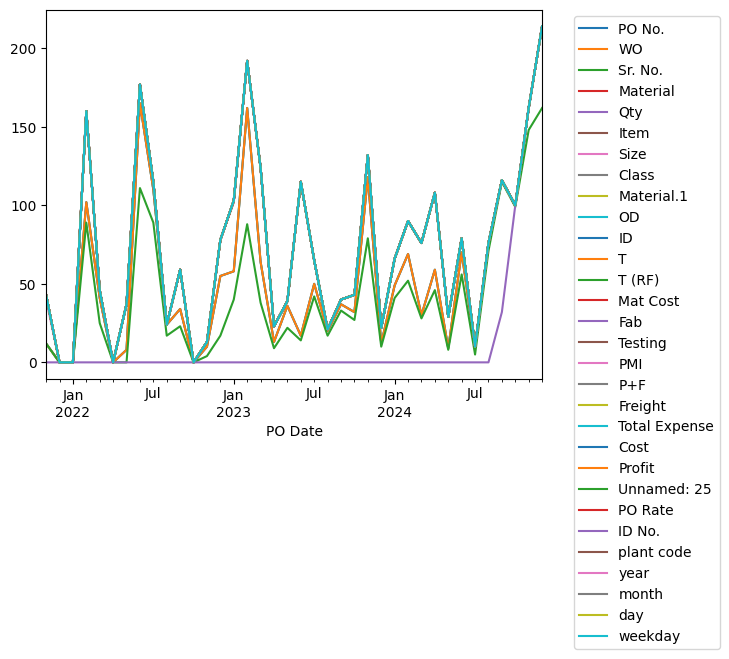

In [ ]:
df.set_index('PO Date').resample('Me').count().plot()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

<ipython-input-53-98065023331e>:1: FutureWarning: 'Me' is deprecated and will be removed in a future version, please use 'ME' instead.
  df[['Profit', 'Total Expense']].set_index(df['PO Date']).resample('Me').count().plot()


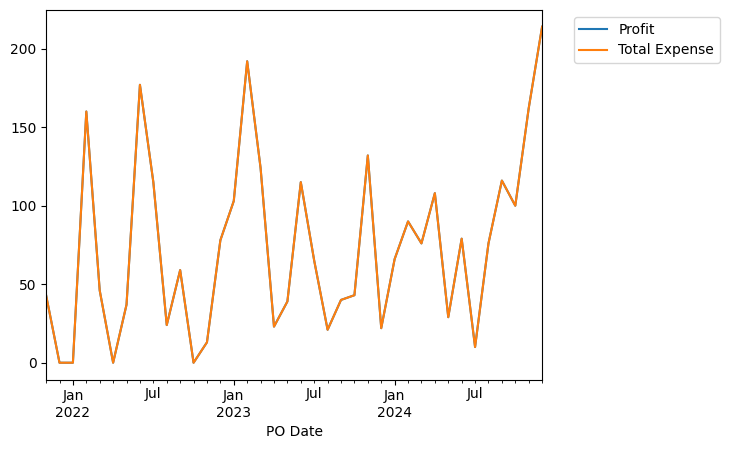

In [ ]:
df[['Profit', 'Total Expense']].set_index(df['PO Date']).resample('Me').count().plot()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

In [ ]:
df['Size'] = df['Size'].astype('category')

In [ ]:
df['Size'].dtype

CategoricalDtype(categories=[ 0.5, 0.75,  1.0, 1.25,  1.5,  2.0,  2.5,  3.0,  4.0,  6.0,
                   8.0, 10.0, 12.0, 14.0, 16.0, 18.0, 20.0, 22.0, 24.0, 26.0,
                  30.0, 32.0, 36.0, 40.0, 42.0, 48.0, 60.0],
, ordered=False, categories_dtype=float64)

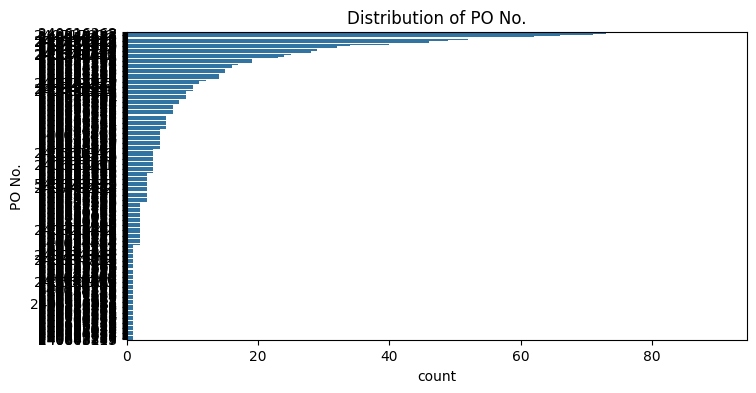

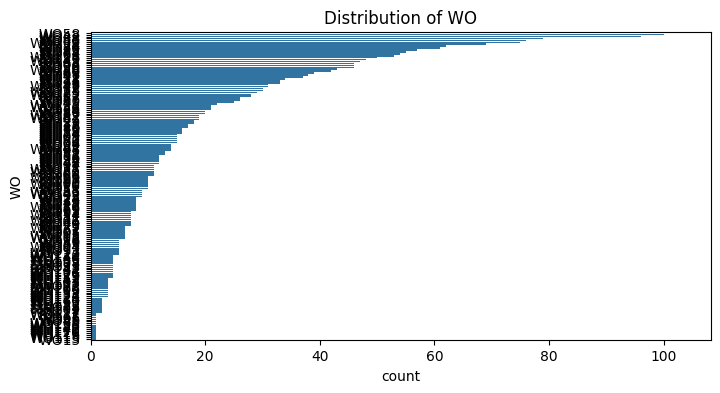

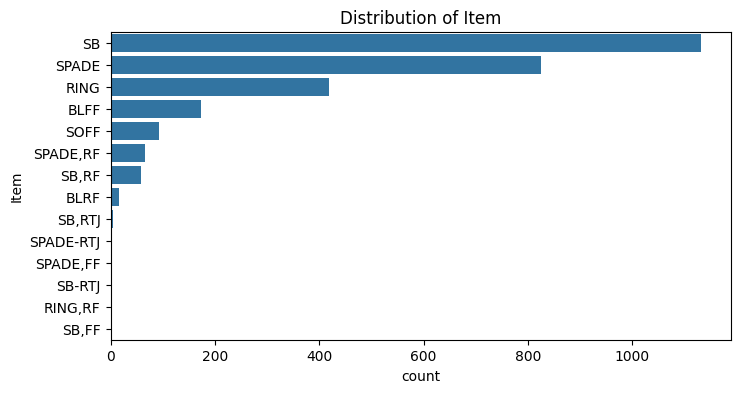

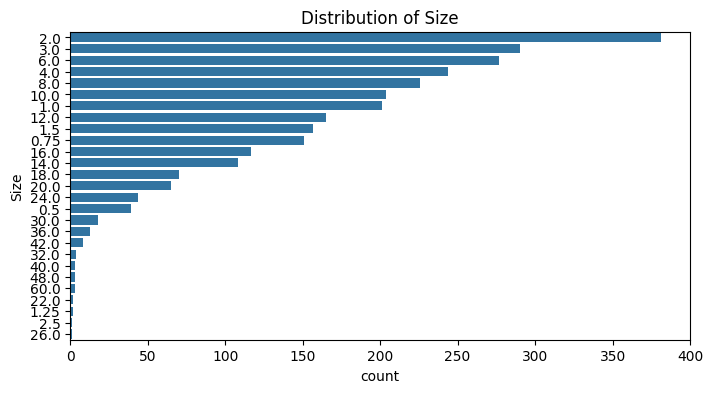

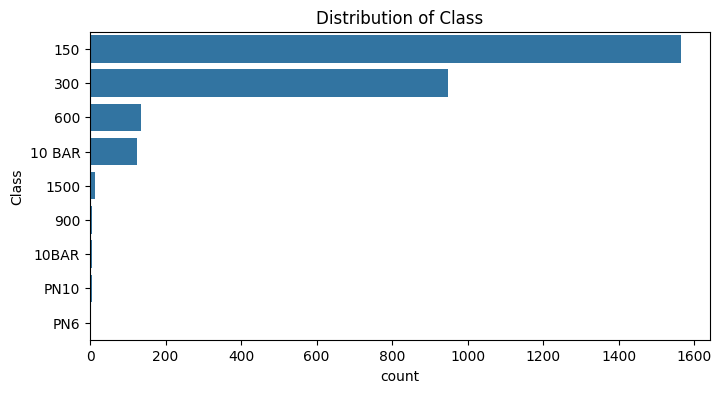

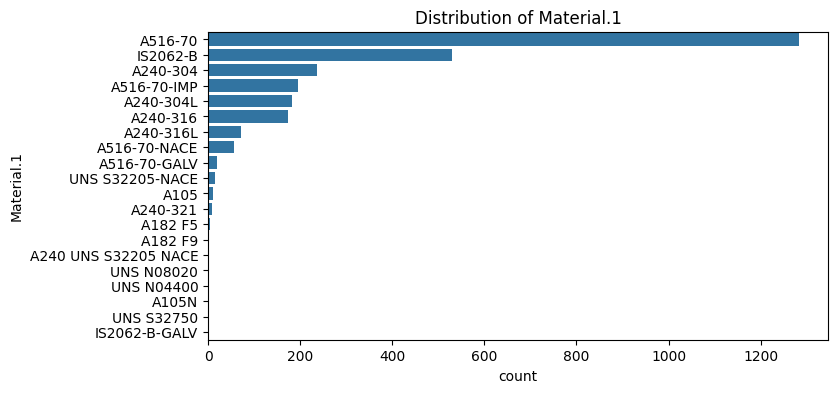

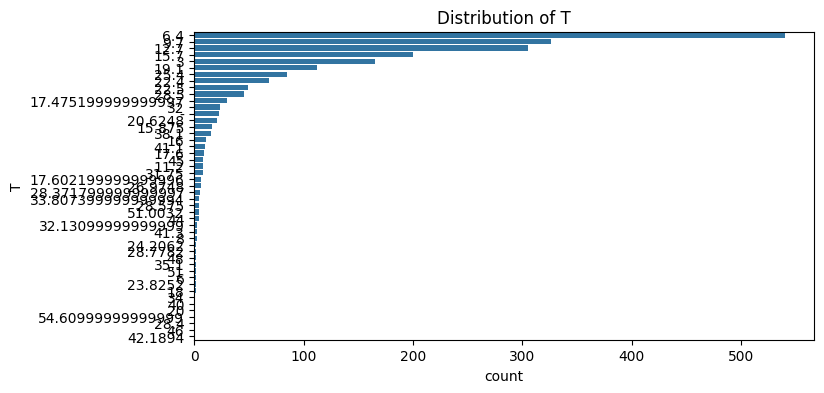

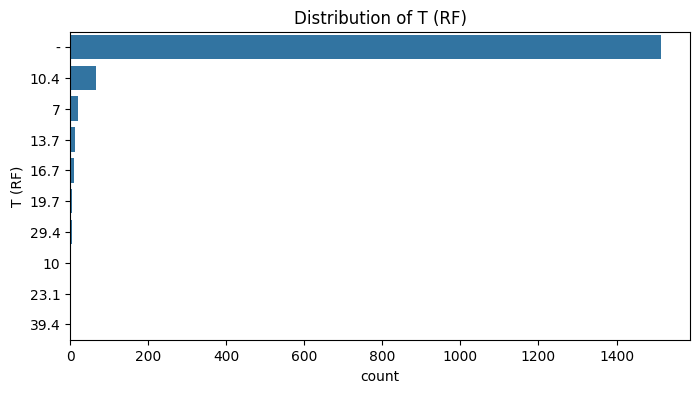

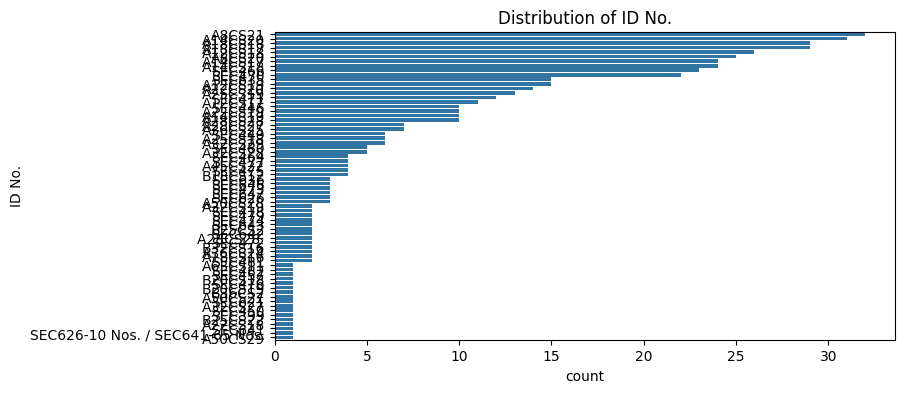

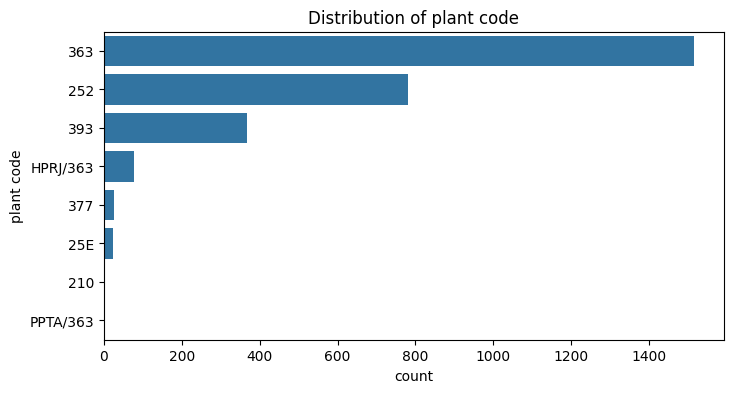

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in df.select_dtypes(include=['object', 'category']):
    plt.figure(figsize=(8, 4))
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.show()

In [ ]:
df.isnull().sum()

,0
PO No.,0
PO Date,0
WO,0
Sr. No.,0
Material,0
Qty,0
Item,0
Size,0
Class,0
Material.1,0


In [ ]:
df_no_nulls = df_no_nulls.drop(columns='T (RF)')

(2797, 31)

In [ ]:
df_no_nulls.shape

(2797, 30)

In [ ]:
df_no_nulls = df_no_nulls.drop(columns = 'ID No.')

KeyError: "['ID No.'] not found in axis"

In [ ]:
df_no_nulls.shape

(2797, 29)

In [ ]:
df_no_nulls.columns

Index(['PO No.', 'PO Date', 'WO', 'Sr. No.', 'Material', 'Qty', 'Item', 'Size',
       'Class', 'Material.1', 'OD', 'ID', 'T', 'Mat Cost', 'Fab', 'Testing',
       'PMI', 'P+F', 'Freight', 'Total Expense', 'Cost', 'Profit',
       'Unnamed: 25', 'PO Rate', 'plant code', 'year', 'month', 'day',
       'weekday'],
      dtype='object')

In [ ]:
df_no_nulls.isnull().sum()

,0
PO No.,0
PO Date,0
WO,0
Sr. No.,0
Material,0
Qty,0
Item,0
Size,0
Class,0
Material.1,0


In [ ]:
df_no_nulls.shape

(2797, 29)

In [ ]:
df_no_nulls.isnull().sum()

,0
PO No.,0
PO Date,0
WO,0
Sr. No.,0
Material,0
Qty,0
Item,0
Size,0
Class,0
Material.1,0


In [ ]:
df_no_nulls = df_no_nulls.dropna(axis = 0)

In [ ]:
df_no_nulls.shape

(2143, 29)

In [ ]:
df_no_nulls.isnull().sum().sum()

0

In [ ]:
cleandf = df_no_nulls

In [ ]:
cleandf = df_no_nulls.drop(columns = 'PO No.')

In [ ]:
cleandf.shape

(2143, 28)

Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
label_encoders = {}
for col in cleandf.select_dtypes(include=['object', 'category']).columns:
    # Check if the column has mixed types
    if cleandf[col].apply(type).nunique() > 1:
        # Convert all values to strings
        cleandf[col] = cleandf[col].astype(str)
    # Now apply Label Encoding
    le = LabelEncoder()
    cleandf[col] = le.fit_transform(cleandf[col])
    label_encoders[col] = le

cleandf.head()

,PO Date,WO,Sr. No.,Material,Qty,Item,Size,Class,Material.1,OD,...,Total Expense,Cost,Profit,Unnamed: 25,PO Rate,plant code,year,month,day,weekday
3,2021-11-23,85,1,2001437217,1,3,4,2,9,83.0,...,320,640.0,0.15,96.00,750.0,2,2021,11,23,1
4,2021-11-23,85,2,2001437217,2,3,4,2,9,83.0,...,320,640.0,0.15,96.00,750.0,2,2021,11,23,1
5,2021-11-23,85,3,2002006552,3,3,5,2,9,102.0,...,350,725.0,0.15,108.75,850.0,2,2021,11,23,1
6,2021-11-23,86,1,2001685119,3,7,5,2,5,102.0,...,620,1095.0,0.20,219.00,1350.0,2,2021,11,23,1
7,2021-11-23,86,2,2001613535,5,3,7,2,5,133.0,...,950,2350.0,0.15,352.50,2750.0,2,2021,11,23,1


In [ ]:
cleandf.shape

(2143, 28)

In [ ]:
import pandas as pd

cleandf['PO Date'] = pd.to_datetime(cleandf['PO Date'])
cleandf = cleandf.sort_values(by='PO Date')
cleandf.set_index('PO Date', inplace=True)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
clean_df_scaled = scaler.fit_transform(cleandf)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Separate scaler for the target column
target_scaler = MinMaxScaler()
clean_df_scaled[:, target_col_index] = target_scaler.fit_transform(cleandf[['Profit']]).ravel()  # Fit only on the target

# Train-Test Split and Sequence Creation remains the same...

# When inverse transforming:
y_pred_rescaled = target_scaler.inverse_transform(y_pred)

In [ ]:
train_size = int(len(clean_df_scaled) * 0.8)
train_data = clean_df_scaled[:train_size]
test_data = clean_df_scaled[train_size:]

In [ ]:
import numpy as np

def create_sequences(data, target_col_index, time_steps=10):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])  # Past `time_steps` values as input
        y.append(data[i+time_steps, target_col_index])  # Target at the next step
    return np.array(X), np.array(y)

# Define parameters
time_steps = 10  # Number of past observations to use
target_col_index = cleandf.columns.get_loc('Profit')

# Create sequences for training
X_train, y_train = create_sequences(train_data, target_col_index, time_steps)

# Create sequences for testing
X_test, y_test = create_sequences(test_data, target_col_index, time_steps)

# Reshape for LSTM (samples, time steps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], X_train.shape[2]))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], X_test.shape[2]))


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Define the LSTM model
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)  # Single output for regression
])

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=16, validation_data=(X_test, y_test))


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.0046 - val_loss: 1.4555e-04
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0021 - val_loss: 7.8439e-05
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0018 - val_loss: 3.0804e-05
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0016 - val_loss: 8.7910e-06
Epoch 5/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0018 - val_loss: 1.0871e-05
Epoch 6/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0019 - val_loss: 5.3357e-06
Epoch 7/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.0373e-04 - val_loss: 1.5031e-05
Epoch 8/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.0420e-04 - val_loss: 1.5461e-04
Epoch 9/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0013 - val_loss: 1.1238e-04
Epoch 10/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0032 - val_loss: 1.2805e-05


In [ ]:
model.save('lstm_model.h5')

In [ ]:
y_train_pred = model.predict(X_train)
y_train_rescaled = target_scaler.inverse_transform(y_train_pred)
train_mae = mean_absolute_error(y_train_rescaled, y_train)
train_mse = mean_squared_error(y_train_rescaled, y_train)
print(f"Train MAE: {train_mae}, Train MSE: {train_mse}")

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Train MAE: 2.1425737452698215, Train MSE: 8.946056917853236


In [ ]:
y_pred = model.predict(X_test)

# Convert predictions back to original scale
y_pred_rescaled = target_scaler.inverse_transform(y_pred)

# Evaluate Model Performance
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f"MAE: {mae}, MSE: {mse}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
MAE: 0.003093687127780027, MSE: 1.2805170189866855e-05


In [ ]:
from tensorflow.keras.models import load_model

# Load the saved model
loaded_model = load_model('lstm_model.h5')

# Use the model for predictions
y_pred = loaded_model.predict(X_test)
y_pred_rescaled = target_scaler.inverse_transform(y_pred)


In [ ]:
y_test

array([5.71477555e-05, 1.57156328e-04, 7.14346944e-05, 2.57164900e-04,
       7.14346944e-05, 5.71477555e-05, 1.28582450e-04, 1.28582450e-04,
       5.71477555e-05, 1.28582450e-04, 1.28582450e-04, 2.71451839e-04,
       1.71443267e-04, 7.14346944e-05, 1.28582450e-04, 4.28608166e-05,
       8.57216333e-05, 0.00000000e+00, 5.71477555e-05, 7.14346944e-05,
       7.14346944e-05, 2.00017144e-04, 1.28582450e-04, 1.28582450e-04,
       3.42886533e-04, 2.00017144e-04, 1.28582450e-04, 1.28582450e-04,
       1.28582450e-04, 8.57216333e-05, 8.57216333e-05, 7.14346944e-05,
       1.28582450e-04, 1.00008572e-04, 1.00008572e-04, 5.71477555e-05,
       1.28582450e-04, 1.28582450e-04, 3.28599594e-04, 1.28582450e-04,
       2.71451839e-04, 2.00017144e-04, 1.14295511e-04, 3.28599594e-04,
       4.00034289e-04, 8.57216333e-05, 2.00017144e-04, 1.28582450e-04,
       1.00008572e-04, 1.42869389e-04, 1.28582450e-04, 1.14295511e-04,
       4.28608166e-05, 1.85730205e-04, 4.28608166e-05, 4.28608166e-05,
      

In [ ]:
y_pred

array([[-2.5372938e-03],
       [-1.7815144e-03],
       [-6.0334709e-04],
       [ 4.8609311e-04],
       [ 4.4395961e-04],
       [ 8.3571719e-04],
       [ 1.4838921e-03],
       [ 1.7441874e-03],
       [ 1.1918801e-03],
       [ 9.7456155e-04],
       [ 9.6333725e-04],
       [ 3.8120383e-04],
       [-5.6281034e-04],
       [-1.6740179e-03],
       [-2.4174238e-03],
       [-3.3744359e-03],
       [-4.0785940e-03],
       [-3.7096459e-03],
       [-3.5245158e-03],
       [-3.4303488e-03],
       [-3.2917410e-03],
       [-2.6975349e-03],
       [-2.3515392e-03],
       [-2.4843500e-03],
       [-3.0244133e-03],
       [-3.5126111e-03],
       [-3.4716297e-03],
       [-3.8552810e-03],
       [-4.2209500e-03],
       [-4.8177284e-03],
       [-4.5337281e-03],
       [-4.5730369e-03],
       [-4.1316403e-03],
       [-4.0693032e-03],
       [-3.9560096e-03],
       [-3.6110259e-03],
       [-3.5258769e-03],
       [-3.2548648e-03],
       [-3.0176011e-03],
       [-3.0310652e-03],
